In [20]:
# 1) Création du venv
!python -m venv .venv

# 2) Installation des libs dans le venv via le pip du venv
!.venv\Scripts\python -m pip install --upgrade pip
!.venv\Scripts\pip install -r requirements.txt

Unable to copy 'C:\\Users\\lucas\\AppData\\Local\\Programs\\Python\\Python313\\Lib\\venv\\scripts\\nt\\venvlauncher.exe' to 'c:\\Users\\lucas\\OneDrive\\Documents\\Perso\\Bloc IA\\Projet ML\\.venv\\Scripts\\python.exe'


# 🏢 Projet ML - Système de Prédiction RH

Ce notebook implémente un système complet de comparaison de modèles ML pour prédire l'attrition des employés (départ de l'entreprise).

## 📋 Contenu
1. **Prétraitement des données** - Extraction et fusion des fichiers CSV
2. **Chargement et préparation des données**
3. **Définition des modèles**
4. **Réglage des hyperparamètres (optionnel)**
5. **Entraînement et évaluation**
6. **Comparaison des modèles**
7. **Validation croisée**

## 🔧 ÉTAPE 0 - Prétraitement des Données Brutes

### Extraction du fichier ZIP

Les données sont dans un fichier `in_out_time.zip` qui contient plusieurs fichiers CSV.

In [21]:
import shutil
import os

data_root="data/"

# Extraire le fichier ZIP s'il existe
if os.path.exists(data_root + 'in_out_time.zip'):
    print("📦 Extraction du fichier in_out_time.zip...")
    shutil.unpack_archive(data_root + 'in_out_time.zip', data_root)
    print("✅ Extraction terminée")
else:
    print("⚠️ Le fichier in_out_time.zip n'existe pas. Vérifiez que les fichiers CSV sont déjà extraits.")

📦 Extraction du fichier in_out_time.zip...
✅ Extraction terminée


### Fusion des fichiers CSV

Les données RH sont réparties dans 5 fichiers différents :
- `general_data.csv` - Données générales des employés
- `employee_survey_data.csv` - Enquête auprès des employés
- `manager_survey_data.csv` - Enquête auprès des managers
- `in_time.csv` - Heures d'arrivée
- `out_time.csv` - Heures de départ

Nous allons les fusionner via l'`EmployeeID`.

In [22]:
import pandas as pd
import glob

# Vérifier la présence des fichiers
required_files = [data_root + 'general_data.csv', data_root + 'employee_survey_data.csv', data_root + 'manager_survey_data.csv', 
                  data_root + 'in_time.csv', data_root + 'out_time.csv']
missing_files = [f for f in required_files if not os.path.exists(f)]

if missing_files:
    print(f"❌ Fichiers manquants: {missing_files}")
    print("⚠️ Assurez-vous d'avoir extrait le fichier ZIP ou que les CSV sont présents.")
else:
    print("📊 Chargement des fichiers CSV...")
    
    # Charger les fichiers principaux
    df1 = pd.read_csv(data_root + 'general_data.csv')
    df2 = pd.read_csv(data_root + 'employee_survey_data.csv')
    df3 = pd.read_csv(data_root + 'manager_survey_data.csv')
    
    print(f"  - general_data.csv: {df1.shape}")
    print(f"  - employee_survey_data.csv: {df2.shape}")
    print(f"  - manager_survey_data.csv: {df3.shape}")
    
    # Charger les fichiers temporels
    df4 = pd.read_csv(data_root + 'in_time.csv')
    df5 = pd.read_csv(data_root + 'out_time.csv')
    
    print(f"  - in_time.csv: {df4.shape}")
    print(f"  - out_time.csv: {df5.shape}")
    
    # Renommer la première colonne des fichiers in/out time
    df4 = df4.rename(columns={'Unnamed: 0': 'EmployeeID'})
    df5 = df5.rename(columns={'Unnamed: 0': 'EmployeeID'})
    
    print("\n🔧 Création de features agrégées à partir des données temporelles...")
    print("   (Pour éviter l'explosion de mémoire avec 1M+ colonnes)")
    
    # Créer des features agrégées au lieu d'utiliser toutes les colonnes de dates
    def create_time_features(df_time, prefix='in'):
        """Créer des features agrégées à partir des heures d'arrivée/départ"""
        # Sélectionner seulement les colonnes de dates (pas EmployeeID)
        date_cols = [col for col in df_time.columns if col != 'EmployeeID']
        
        # Convertir en format datetime
        df_values = df_time[date_cols].apply(pd.to_datetime, errors='coerce')
        
        # Extraire l'heure en format numérique (heures + minutes/60)
        df_hours = df_values.apply(lambda x: x.dt.hour + x.dt.minute/60.0)
        
        # Calculer des statistiques agrégées
        features = pd.DataFrame()
        features['EmployeeID'] = df_time['EmployeeID']
        features[f'{prefix}_avg_hour'] = df_hours.mean(axis=1)  # Heure moyenne
        features[f'{prefix}_std_hour'] = df_hours.std(axis=1)   # Variabilité
        features[f'{prefix}_min_hour'] = df_hours.min(axis=1)   # Plus tôt
        features[f'{prefix}_max_hour'] = df_hours.max(axis=1)   # Plus tard
        features[f'{prefix}_missing_days'] = df_values.isna().sum(axis=1)  # Jours manquants
        
        return features
    
    # Créer les features pour in_time et out_time
    in_features = create_time_features(df4, prefix='arrival')
    out_features = create_time_features(df5, prefix='departure')
    
    # Fusionner les features temporelles
    time_features = in_features.merge(out_features, on='EmployeeID', how='inner')
    
    # Calculer le temps de travail moyen
    time_features['avg_work_hours'] = (
        time_features['departure_avg_hour'] - time_features['arrival_avg_hour']
    )
    
    print(f"  - Features temporelles créées: {time_features.shape[1]-1} colonnes")
    
    print("\n🔗 Fusion des données...")
    # Fusion en chaîne (2 par 2)
    resultat = df1.merge(df2, on='EmployeeID', how='inner') \
                  .merge(df3, on='EmployeeID', how='inner') \
                  .merge(time_features, on='EmployeeID', how='inner')
    
    # Suppression des colonnes inutiles
    colonnes_a_supprimer = ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeID']
    colonnes_existantes = [col for col in colonnes_a_supprimer if col in resultat.columns]
    
    if colonnes_existantes:
        resultat = resultat.drop(colonnes_existantes, axis=1)
        print(f"  - Colonnes supprimées: {colonnes_existantes}")
    
    # Sauvegarder
    resultat.to_csv('Dataset_clean.csv', index=False)
    
    print(f"\n✅ Dataset fusionné et sauvegardé dans 'Dataset_clean.csv'")
    print(f"   Dimensions: {resultat.shape[0]} lignes × {resultat.shape[1]} colonnes")
    print(f"\n📋 Aperçu des colonnes:")
    print(f"   Colonnes générales: {list(df1.columns[:5])}...")
    print(f"   Features temporelles: {list(time_features.columns[1:6])}...")
    
    # Afficher les premières lignes
    print(f"\n📊 Aperçu des données:")
    display(resultat.head())
    
    # Vérifier les valeurs manquantes
    print(f"\n🔍 Valeurs manquantes par colonne:")
    missing = resultat.isnull().sum()
    if missing.sum() > 0:
        display(missing[missing > 0])
    else:
        print("   Aucune valeur manquante !")

📊 Chargement des fichiers CSV...
  - general_data.csv: (4410, 24)
  - employee_survey_data.csv: (4410, 4)
  - manager_survey_data.csv: (4410, 3)
  - in_time.csv: (4410, 262)
  - out_time.csv: (4410, 262)

🔧 Création de features agrégées à partir des données temporelles...
   (Pour éviter l'explosion de mémoire avec 1M+ colonnes)
  - Features temporelles créées: 11 colonnes

🔗 Fusion des données...
  - Colonnes supprimées: ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeID']

✅ Dataset fusionné et sauvegardé dans 'Dataset_clean.csv'
   Dimensions: 4410 lignes × 36 colonnes

📋 Aperçu des colonnes:
   Colonnes générales: ['Age', 'Attrition', 'BusinessTravel', 'Department', 'DistanceFromHome']...
   Features temporelles: ['arrival_avg_hour', 'arrival_std_hour', 'arrival_min_hour', 'arrival_max_hour', 'arrival_missing_days']...

📊 Aperçu des données:


,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,Gender,JobLevel,JobRole,...,arrival_std_hour,arrival_min_hour,arrival_max_hour,arrival_missing_days,departure_avg_hour,departure_std_hour,departure_min_hour,departure_max_hour,departure_missing_days,avg_work_hours
0,51,No,Travel_Rarely,Sales,6,2,Life Sciences,Female,1,Healthcare Representative,...,0.258456,9.216667,10.616667,29,17.367170,0.373791,16.300000,18.233333,29,7.374138
1,31,Yes,Travel_Frequently,Research & Development,10,1,Life Sciences,Female,1,Research Scientist,...,0.293095,9.200000,10.716667,25,17.698446,0.418810,16.450000,18.816667,25,7.717726
2,32,No,Travel_Frequently,Research & Development,17,4,Other,Male,4,Sales Executive,...,0.272513,9.133333,10.866667,19,17.030096,0.395190,15.966667,18.116667,19,7.013499
3,38,No,Non-Travel,Research & Development,2,5,Life Sciences,Male,3,Human Resources,...,0.282750,9.200000,10.833333,26,17.167305,0.407105,16.033333,18.166667,26,7.193475
4,32,No,Travel_Rarely,Research & Development,10,1,Medical,Male,1,Sales Executive,...,0.270862,9.300000,10.900000,16,17.996327,0.405745,16.883333,19.366667,16,8.006259



🔍 Valeurs manquantes par colonne:


NumCompaniesWorked         19
TotalWorkingYears           9
EnvironmentSatisfaction    25
JobSatisfaction            20
WorkLifeBalance            38
dtype: int64

## 2️⃣ Chargement et Préparation des Données

Nous allons utiliser le fichier `Dataset_clean.csv` créé lors du prétraitement.

In [23]:
# Imports standards
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Modèles
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import GaussianNB
from sklearn.calibration import CalibratedClassifierCV

# Métriques
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, 
    classification_report, confusion_matrix, 
    roc_curve, precision_recall_curve, average_precision_score
)

# Configuration des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

print("✅ Imports terminés")

✅ Imports terminés


## 1️⃣ Imports et Configuration

In [24]:
def get_data_pipeline(csv_path, target_column='Attrition'):
    """
    Créer le pipeline de chargement et prétraitement des données:
    1. Remplir les valeurs manquantes (médiane pour numérique, mode pour catégoriel)
    2. Transformer les données catégorielles avec OneHotEncoder
    3. Standardisation
    
    Args:
        csv_path: chemin vers le fichier CSV
        target_column: nom de la colonne cible (par défaut 'Attrition')
    """
    print(f"[Loader] Chargement des données depuis: {csv_path}")
    
    # 1. CHARGER LES DONNÉES
    try:
        df = pd.read_csv(csv_path)
        df.columns = df.columns.str.strip()
    except FileNotFoundError:
        raise FileNotFoundError(f"Fichier introuvable: {csv_path}")

    print(f"[Loader] Dataset chargé: {df.shape[0]} lignes × {df.shape[1]} colonnes")
    
    # Vérifier si la colonne cible existe
    if target_column not in df.columns:
        print(f"\n⚠️ La colonne '{target_column}' n'existe pas.")
        print(f"📋 Colonnes disponibles: {list(df.columns[:20])}")
        raise ValueError(f"Colonne cible '{target_column}' introuvable dans le dataset")
    
    # Séparer features X et target y
    blacklist = []  # Liste pour éviter les fuites de données si nécessaire
    cols_to_drop = [c for c in blacklist if c in df.columns]
    
    if cols_to_drop:
        df = df.drop(cols_to_drop, axis=1)
        print(f"[Loader] Colonnes supprimées: {cols_to_drop}")
    
    X = df.drop(target_column, axis=1)
    y = df[target_column]
    
    # Convertir la cible en format binaire si nécessaire (Yes/No -> 1/0)
    if y.dtype == 'object':
        print(f"[Loader] Conversion de la variable cible en format binaire")
        y = y.map({'Yes': 1, 'No': 0})
        if y.isnull().any():
            print(f"⚠️ Valeurs non converties détectées dans la cible")

    # 2. SPLIT train-test (80%/20%)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # 3. PIPELINE DE PRÉTRAITEMENT
    numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    categorical_features = X.select_dtypes(include=['object']).columns.tolist()
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=True))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features)
        ]
    )
    
    print(f"[Loader] Features numériques: {len(numeric_features)}")
    print(f"[Loader] Features catégorielles: {len(categorical_features)}")

    return X_train, X_test, y_train, y_test, preprocessor

print("✅ Fonction de chargement définie")

✅ Fonction de chargement définie


In [25]:
# Charger les données
print("🔄 Chargement des données RH...\n")

# Vérifier si le fichier existe
if not os.path.exists("Dataset_clean.csv"):
    print("❌ Le fichier 'Dataset_clean.csv' n'existe pas.")
    print("⚠️ Veuillez exécuter les cellules de prétraitement ci-dessus d'abord.")
    raise FileNotFoundError("Dataset_clean.csv introuvable. Exécutez d'abord le prétraitement.")

# Charger avec la colonne cible appropriée (Attrition pour les données RH)
X_train, X_test, y_train, y_test, preprocessor = get_data_pipeline(
    "Dataset_clean.csv", 
    target_column='Attrition'  # Changez si votre colonne cible a un autre nom
)

print(f"\n📊 Dimensions des données:")
print(f"   - X_train: {X_train.shape}")
print(f"   - X_test: {X_test.shape}")
print(f"   - y_train: {y_train.shape}")
print(f"   - y_test: {y_test.shape}")

# Afficher la distribution de la target
print(f"\n🎯 Distribution de la variable cible (y_train):")
print(y_train.value_counts())
print(f"\n📊 Proportion:")
display(y_train.value_counts(normalize=True).to_frame('Proportion'))

🔄 Chargement des données RH...

[Loader] Chargement des données depuis: Dataset_clean.csv
[Loader] Dataset chargé: 4410 lignes × 36 colonnes
[Loader] Conversion de la variable cible en format binaire
[Loader] Features numériques: 29
[Loader] Features catégorielles: 6

📊 Dimensions des données:
   - X_train: (3528, 35)
   - X_test: (882, 35)
   - y_train: (3528,)
   - y_test: (882,)

🎯 Distribution de la variable cible (y_train):
Attrition
0    2959
1     569
Name: count, dtype: int64

📊 Proportion:


,Proportion
Attrition,
0,0.838719
1,0.161281


## 3️⃣ Définition des Modèles

In [26]:
def create_logistic_model(preprocessor):
    """Régression Logistique"""
    model = LogisticRegression(random_state=42, max_iter=1000)
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    return pipeline

def create_perceptron_model(preprocessor):
    """Perceptron avec calibration pour predict_proba"""
    base_model = Perceptron(random_state=42, max_iter=1000)
    calibrated_model = CalibratedClassifierCV(base_model, cv=3)
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', calibrated_model)
    ])
    return pipeline

def create_decision_tree_model(preprocessor):
    """Arbre de Décision"""
    model = DecisionTreeClassifier(random_state=42)
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    return pipeline

def create_random_forest_model(preprocessor):
    """Forêt Aléatoire"""
    model = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=4)
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    return pipeline

def create_svm_model(preprocessor):
    """SVM Linéaire avec calibration"""
    base_model = LinearSVC(random_state=42, max_iter=1000)
    calibrated_model = CalibratedClassifierCV(base_model, cv=3)
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', calibrated_model)
    ])
    return pipeline

def create_naive_bayes_model(preprocessor):
    """Naive Bayes (Gaussian)"""
    # Créer un preprocessor modifié pour Naive Bayes (sparse_output=False)
    numeric_features = preprocessor.transformers[0][2]
    categorical_features = preprocessor.transformers[1][2]
    
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])
    
    preprocessor_nb = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features)
        ]
    )
    
    model = GaussianNB()
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor_nb),
        ('classifier', model)
    ])
    return pipeline

print("✅ Fonctions de création de modèles définies")

✅ Fonctions de création de modèles définies


In [27]:
# Créer tous les modèles
print("🔨 Création des modèles...\n")

competitors = {
    "Logistic Regression": create_logistic_model(preprocessor),
    "Perceptron": create_perceptron_model(preprocessor),
    "Decision Tree": create_decision_tree_model(preprocessor),
    "Random Forest": create_random_forest_model(preprocessor),
    "Support Vector Machine": create_svm_model(preprocessor),
    "Naive Bayes": create_naive_bayes_model(preprocessor)
}

print(f"✅ {len(competitors)} modèles créés:")
for name in competitors.keys():
    print(f"   - {name}")

🔨 Création des modèles...

✅ 6 modèles créés:
   - Logistic Regression
   - Perceptron
   - Decision Tree
   - Random Forest
   - Support Vector Machine
   - Naive Bayes


## 4️⃣ Réglage des Hyperparamètres (Optionnel)

⚠️ Cette étape peut prendre du temps. Mettez `enable_tuning = True` pour activer.

In [28]:
def get_param_grids():
    """Grilles de paramètres pour le tuning"""
    param_grids = {
        'Logistic Regression': {
            'classifier__C': [0.1, 1, 10],
            'classifier__max_iter': [1000, 5000]
        },
        'Decision Tree': {
            'classifier__max_depth': [5, 10, 15],
            'classifier__min_samples_split': [2, 5],
            'classifier__min_samples_leaf': [1, 2]
        },
        'Random Forest': {
            'classifier__n_estimators': [100, 200],
            'classifier__max_depth': [10, 15, 20],
            'classifier__min_samples_split': [2, 5]
        },
        'Naive Bayes': {
            'classifier__var_smoothing': [1e-9, 1e-8, 1e-7]
        },
        'Support Vector Machine': {
            'classifier__estimator__C': [0.1, 1, 10],
            'classifier__estimator__max_iter': [1000, 5000]
        },
        'Perceptron': {
            'classifier__estimator__alpha': [0.001, 0.01, 0.1],
            'classifier__estimator__max_iter': [1000, 5000]
        }
    }
    return param_grids

def tune_model(model_pipeline, X_train, y_train, model_name, cv=5, scoring='f1'):
    """Optimiser un modèle avec GridSearchCV"""
    param_grids = get_param_grids()
    
    if model_name not in param_grids:
        print(f"[Warning] Pas de grille définie pour {model_name}")
        return model_pipeline, {}, None
    
    param_grid = param_grids[model_name]
    
    print(f"\n[Tuning] Optimisation: {model_name}")
    
    grid_search = GridSearchCV(
        model_pipeline,
        param_grid,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        verbose=1
    )
    
    grid_search.fit(X_train, y_train)
    
    print(f"  Meilleurs params: {grid_search.best_params_}")
    print(f"  Meilleur score CV ({scoring}): {grid_search.best_score_:.4f}")
    
    return grid_search.best_estimator_, grid_search.best_params_, grid_search.best_score_

def tune_all_models(competitors, X_train, y_train, cv=5, scoring='f1'):
    """Optimiser tous les modèles"""
    tuned_competitors = {}
    tuning_results = {}
    
    print("\n" + "="*60)
    print("🔧 Début du réglage des hyperparamètres")
    print("="*60)
    
    for model_name, pipeline in competitors.items():
        best_pipeline, best_params, best_score = tune_model(
            pipeline, X_train, y_train, model_name, cv=cv, scoring=scoring
        )
        tuned_competitors[model_name] = best_pipeline
        tuning_results[model_name] = (best_params, best_score)
    
    print("\n" + "="*60)
    print("✅ Réglage terminé")
    print("="*60)
    
    # Afficher le résumé
    summary_data = []
    for model_name, (best_params, best_score) in tuning_results.items():
        summary_data.append({
            'Model': model_name,
            'Best CV Score (F1)': f"{best_score:.4f}" if best_score else "N/A",
            'Num Params Tuned': len(best_params) if best_params else 0
        })
    
    summary_df = pd.DataFrame(summary_data)
    print("\n📊 Résumé du tuning:")
    display(summary_df)
    
    return tuned_competitors, tuning_results

print("✅ Fonctions de tuning définies")

✅ Fonctions de tuning définies


In [29]:
# Configuration du tuning
enable_tuning = False  # Mettre à True pour activer le tuning

if enable_tuning:
    competitors, tuning_results = tune_all_models(competitors, X_train, y_train, cv=5, scoring='f1')
else:
    print("⏭️ Tuning désactivé. Utilisation des hyperparamètres par défaut.")

⏭️ Tuning désactivé. Utilisation des hyperparamètres par défaut.


## 5️⃣ Entraînement et Évaluation des Modèles

In [30]:
def plot_confusion_matrix(model_name, cm):
    """Dessiner la matrice de confusion"""
    plt.figure(figsize=(4.5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'])
    plt.title(f'Matrice de Confusion - {model_name}')
    plt.xlabel('Prédiction')
    plt.ylabel('Réalité')
    plt.tight_layout()
    plt.show()

def evaluate_model_detailed(model, X_test, y_test, model_name):
    """Évaluation détaillée d'un modèle"""
    print(f"\n{'='*60}")
    print(f"Évaluation: {model_name}")
    print(f"{'='*60}")
    
    # Prédictions
    y_pred = model.predict(X_test)
    
    # Rapport de classification
    print("\n📊 Rapport de classification:")
    print(classification_report(y_test, y_pred))
    
    # Matrice de confusion
    cm = confusion_matrix(y_test, y_pred)
    print(f"\n🔢 Matrice de confusion:")
    print(f"TP (VP): {cm[1][1]} | FP (FP): {cm[0][1]}")
    print(f"FN (FN): {cm[1][0]} | TN (VN): {cm[0][0]}")
    
    plot_confusion_matrix(model_name, cm)
    
    # Métriques
    f1 = f1_score(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    
    # Calculer AUC
    auc = "N/A"
    try:
        if hasattr(model, "predict_proba"):
            proba = model.predict_proba(X_test)
            if proba.ndim == 2:
                auc = roc_auc_score(y_test, proba[:, 1])
            else:
                auc = roc_auc_score(y_test, proba)
        elif hasattr(model, "decision_function"):
            scores = model.decision_function(X_test)
            if getattr(scores, "ndim", 1) == 2:
                auc = roc_auc_score(y_test, scores[:, 1])
            else:
                auc = roc_auc_score(y_test, scores)
    except Exception:
        pass
    
    return {
        "Model": model_name,
        "Accuracy": acc,
        "F1-Score": f1,
        "AUC": auc
    }

print("✅ Fonction d'évaluation définie")

✅ Fonction d'évaluation définie



🚀 DÉBUT DE L'ENTRAÎNEMENT ET DE L'ÉVALUATION

🔄 Entraînement: Logistic Regression...

Évaluation: Logistic Regression

📊 Rapport de classification:
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       740
           1       0.64      0.25      0.36       142

    accuracy                           0.86       882
   macro avg       0.76      0.61      0.64       882
weighted avg       0.83      0.86      0.83       882


🔢 Matrice de confusion:
TP (VP): 36 | FP (FP): 20
FN (FN): 106 | TN (VN): 720


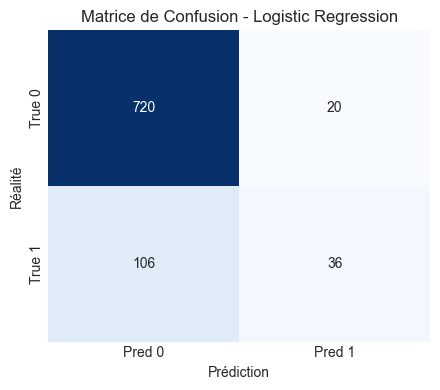


🔄 Entraînement: Perceptron...

Évaluation: Perceptron

📊 Rapport de classification:
              precision    recall  f1-score   support

           0       0.84      1.00      0.91       740
           1       0.00      0.00      0.00       142

    accuracy                           0.84       882
   macro avg       0.42      0.50      0.46       882
weighted avg       0.70      0.84      0.77       882


🔢 Matrice de confusion:
TP (VP): 0 | FP (FP): 0
FN (FN): 142 | TN (VN): 740


c:\Users\lucas\OneDrive\Documents\Perso\Bloc IA\Projet ML\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\lucas\OneDrive\Documents\Perso\Bloc IA\Projet ML\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\lucas\OneDrive\Documents\Perso\Bloc IA\Projet ML\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control thi

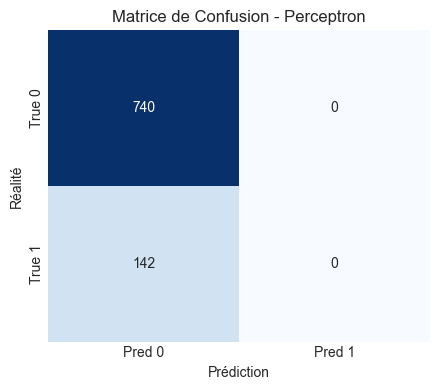


🔄 Entraînement: Decision Tree...

Évaluation: Decision Tree

📊 Rapport de classification:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       740
           1       0.91      0.88      0.89       142

    accuracy                           0.97       882
   macro avg       0.94      0.93      0.94       882
weighted avg       0.97      0.97      0.97       882


🔢 Matrice de confusion:
TP (VP): 125 | FP (FP): 13
FN (FN): 17 | TN (VN): 727


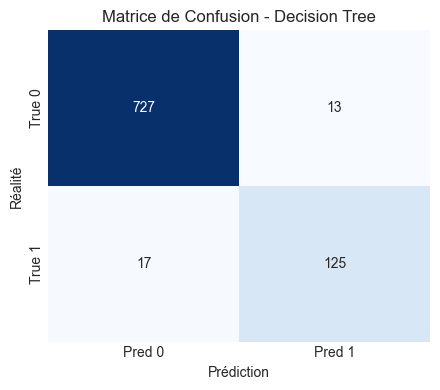


🔄 Entraînement: Random Forest...

Évaluation: Random Forest

📊 Rapport de classification:
              precision    recall  f1-score   support

           0       0.85      1.00      0.92       740
           1       1.00      0.08      0.16       142

    accuracy                           0.85       882
   macro avg       0.93      0.54      0.54       882
weighted avg       0.87      0.85      0.80       882


🔢 Matrice de confusion:
TP (VP): 12 | FP (FP): 0
FN (FN): 130 | TN (VN): 740


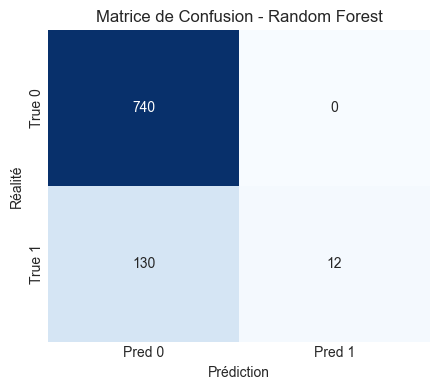


🔄 Entraînement: Support Vector Machine...

Évaluation: Support Vector Machine

📊 Rapport de classification:
              precision    recall  f1-score   support

           0       0.86      0.98      0.92       740
           1       0.61      0.19      0.29       142

    accuracy                           0.85       882
   macro avg       0.74      0.58      0.60       882
weighted avg       0.82      0.85      0.82       882


🔢 Matrice de confusion:
TP (VP): 27 | FP (FP): 17
FN (FN): 115 | TN (VN): 723


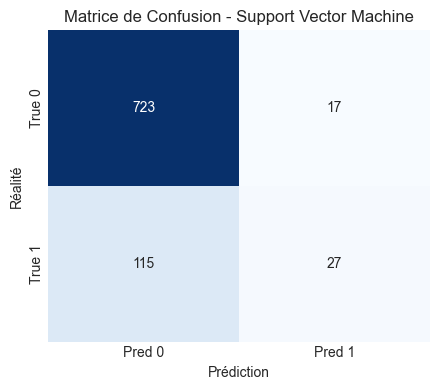


🔄 Entraînement: Naive Bayes...

Évaluation: Naive Bayes

📊 Rapport de classification:
              precision    recall  f1-score   support

           0       0.90      0.88      0.89       740
           1       0.43      0.47      0.45       142

    accuracy                           0.81       882
   macro avg       0.66      0.68      0.67       882
weighted avg       0.82      0.81      0.82       882


🔢 Matrice de confusion:
TP (VP): 67 | FP (FP): 90
FN (FN): 75 | TN (VN): 650


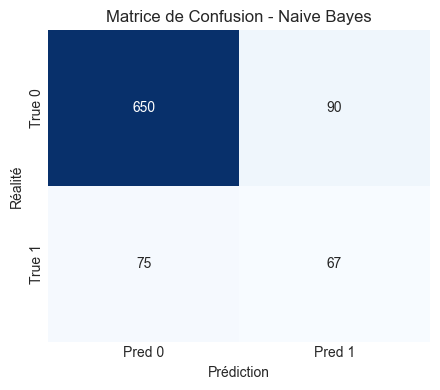


✅ ENTRAÎNEMENT ET ÉVALUATION TERMINÉS


In [31]:
# Entraîner et évaluer tous les modèles
print("\n" + "="*60)
print("🚀 DÉBUT DE L'ENTRAÎNEMENT ET DE L'ÉVALUATION")
print("="*60)

trained_models = {}
results_summary = []

for name, pipeline in competitors.items():
    print(f"\n🔄 Entraînement: {name}...")
    pipeline.fit(X_train, y_train)
    trained_models[name] = pipeline
    
    # Évaluation détaillée
    metrics = evaluate_model_detailed(pipeline, X_test, y_test, name)
    results_summary.append(metrics)

print("\n" + "="*60)
print("✅ ENTRAÎNEMENT ET ÉVALUATION TERMINÉS")
print("="*60)

## 6️⃣ Comparaison des Modèles

In [32]:
# Table de comparaison
results_df = pd.DataFrame(results_summary)
results_df = results_df.sort_values(by="F1-Score", ascending=False)

print("\n" + "#"*60)
print("🏆 COMPARAISON DES MODÈLES")
print("#"*60 + "\n")

display(results_df)

best_model_name = results_df.iloc[0]["Model"]
print(f"\n🥇 Meilleur modèle: {best_model_name}")


############################################################
🏆 COMPARAISON DES MODÈLES
############################################################



,Model,Accuracy,F1-Score,AUC
2,Decision Tree,0.965986,0.892857,0.931357
5,Naive Bayes,0.812925,0.448161,0.764132
0,Logistic Regression,0.857143,0.363636,0.801913
4,Support Vector Machine,0.850340,0.290323,0.802389
3,Random Forest,0.852608,0.155844,0.815350
1,Perceptron,0.839002,0.000000,0.761877



🥇 Meilleur modèle: Decision Tree


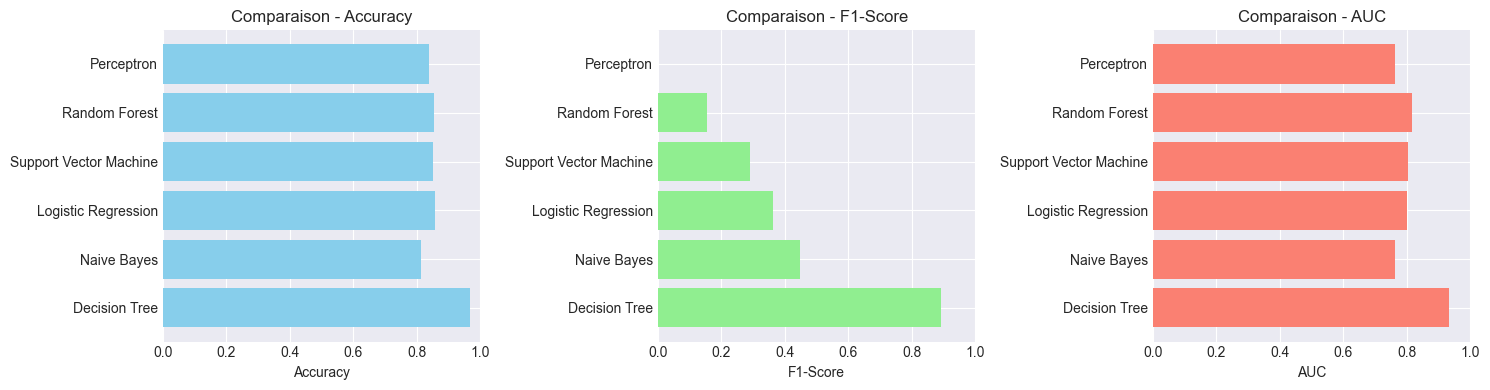

In [33]:
# Visualisation des performances
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Accuracy
axes[0].barh(results_df['Model'], results_df['Accuracy'], color='skyblue')
axes[0].set_xlabel('Accuracy')
axes[0].set_title('Comparaison - Accuracy')
axes[0].set_xlim([0, 1])

# F1-Score
axes[1].barh(results_df['Model'], results_df['F1-Score'], color='lightgreen')
axes[1].set_xlabel('F1-Score')
axes[1].set_title('Comparaison - F1-Score')
axes[1].set_xlim([0, 1])

# AUC
auc_values = [v if isinstance(v, (int, float)) else 0 for v in results_df['AUC']]
axes[2].barh(results_df['Model'], auc_values, color='salmon')
axes[2].set_xlabel('AUC')
axes[2].set_title('Comparaison - AUC')
axes[2].set_xlim([0, 1])

plt.tight_layout()
plt.show()

## 7️⃣ Courbes ROC

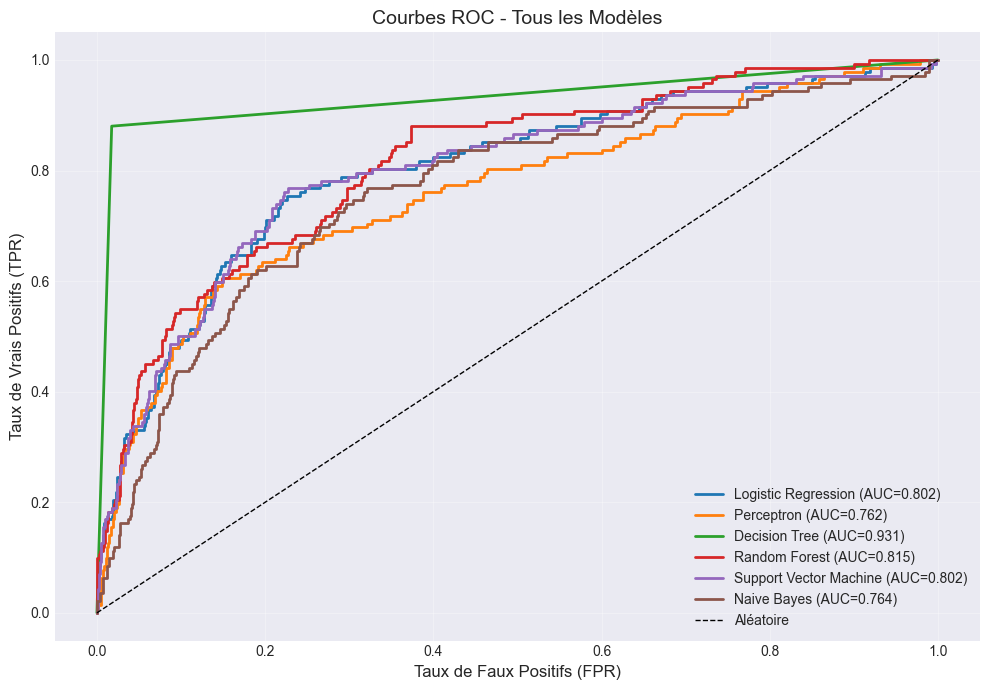

In [34]:
# Courbes ROC pour tous les modèles
plt.figure(figsize=(10, 7))

for name, pipeline in trained_models.items():
    try:
        if hasattr(pipeline, 'predict_proba'):
            proba = pipeline.predict_proba(X_test)
            scores = proba[:, 1] if proba.ndim == 2 else proba
        elif hasattr(pipeline, 'decision_function'):
            scores = pipeline.decision_function(X_test)
            if getattr(scores, 'ndim', 1) == 2:
                scores = scores[:, 1]
        else:
            continue

        fpr, tpr, _ = roc_curve(y_test, scores)
        auc_score = roc_auc_score(y_test, scores)
        plt.plot(fpr, tpr, label=f'{name} (AUC={auc_score:.3f})', linewidth=2)
    except Exception:
        continue

plt.plot([0, 1], [0, 1], 'k--', label='Aléatoire', linewidth=1)
plt.title('Courbes ROC - Tous les Modèles', fontsize=14)
plt.xlabel('Taux de Faux Positifs (FPR)', fontsize=12)
plt.ylabel('Taux de Vrais Positifs (TPR)', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8️⃣ Courbes Précision-Rappel

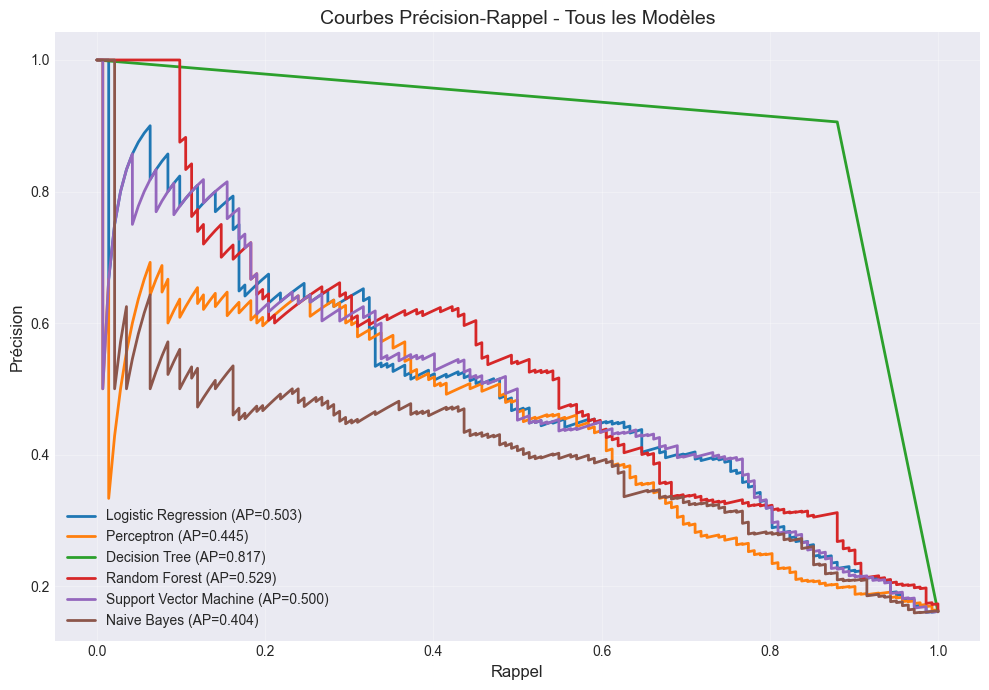

In [35]:
# Courbes Précision-Rappel pour tous les modèles
plt.figure(figsize=(10, 7))

for name, pipeline in trained_models.items():
    try:
        if hasattr(pipeline, 'predict_proba'):
            proba = pipeline.predict_proba(X_test)
            scores = proba[:, 1] if proba.ndim == 2 else proba
        elif hasattr(pipeline, 'decision_function'):
            scores = pipeline.decision_function(X_test)
            scores = scores[:, 1] if getattr(scores, 'ndim', 1) == 2 else scores
        else:
            continue
        
        precision, recall, _ = precision_recall_curve(y_test, scores)
        ap = average_precision_score(y_test, scores)
        plt.plot(recall, precision, label=f"{name} (AP={ap:.3f})", linewidth=2)
    except Exception:
        continue

plt.title('Courbes Précision-Rappel - Tous les Modèles', fontsize=14)
plt.xlabel('Rappel', fontsize=12)
plt.ylabel('Précision', fontsize=12)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9️⃣ Validation Croisée (5-Fold)

In [36]:
def cross_validate_models(competitors, X, y, n_splits=5):
    """Validation croisée stratifiée pour tous les modèles"""
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    cv_summary = []
    
    print("\n" + "="*60)
    print(f"🔄 Validation Croisée {n_splits}-Fold")
    print("="*60 + "\n")
    
    for name, pipeline in competitors.items():
        print(f"Validation: {name}...")
        auc_scores, f1_scores, acc_scores, ap_scores = [], [], [], []
        
        for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
            X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
            y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]
            
            pipeline.fit(X_tr, y_tr)
            y_pred = pipeline.predict(X_te)
            
            acc_scores.append(accuracy_score(y_te, y_pred))
            f1_scores.append(f1_score(y_te, y_pred))
            
            # Calculer AUC et AP
            scores = None
            if hasattr(pipeline, 'predict_proba'):
                proba = pipeline.predict_proba(X_te)
                scores = proba[:, 1] if proba.ndim == 2 else proba
            elif hasattr(pipeline, 'decision_function'):
                scores = pipeline.decision_function(X_te)
                scores = scores[:, 1] if getattr(scores, 'ndim', 1) == 2 else scores
            
            if scores is not None:
                auc_scores.append(roc_auc_score(y_te, scores))
                ap_scores.append(average_precision_score(y_te, scores))
        
        cv_summary.append({
            'Model': name,
            'Acc(mean)': np.mean(acc_scores) if acc_scores else None,
            'F1(mean)': np.mean(f1_scores) if f1_scores else None,
            'AUC(mean)': np.mean(auc_scores) if auc_scores else None,
            'AP(mean)': np.mean(ap_scores) if ap_scores else None,
        })
    
    df = pd.DataFrame(cv_summary)
    print("\n" + "="*60)
    print("📊 Résultats de la Validation Croisée (moyennes)")
    print("="*60 + "\n")
    display(df)
    
    return df

# Exécuter la validation croisée
cv_results = cross_validate_models(competitors, X_train, y_train, n_splits=5)


🔄 Validation Croisée 5-Fold

Validation: Logistic Regression...
Validation: Perceptron...
Validation: Decision Tree...
Validation: Random Forest...
Validation: Support Vector Machine...
Validation: Naive Bayes...

📊 Résultats de la Validation Croisée (moyennes)



,Model,Acc(mean),F1(mean),AUC(mean),AP(mean)
0,Logistic Regression,0.857429,0.374380,0.807565,0.515803
1,Perceptron,0.839853,0.013884,0.772894,0.459668
2,Decision Tree,0.929142,0.783737,0.875425,0.648015
3,Random Forest,0.850056,0.139340,0.819257,0.572223
4,Support Vector Machine,0.856011,0.307655,0.807821,0.507527
5,Naive Bayes,0.803570,0.425503,0.742887,0.374662


## 🎯 Conclusion

Ce notebook a permis de :
1. ✅ Charger et prétraiter les données
2. ✅ Comparer 6 modèles de classification
3. ✅ Évaluer les performances avec plusieurs métriques
4. ✅ Visualiser les résultats avec ROC et PR curves
5. ✅ Valider avec cross-validation

Le meilleur modèle peut maintenant être utilisé pour la production !